In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

import joblib

Loading the dataset

In [3]:
df = pd.read_csv(
    "../data/household_power_consumption.txt",
    sep=';',
    low_memory=False,
    na_values=['?']
)

In [4]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [5]:
df.shape

(2075259, 9)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   str    
 1   Time                   str    
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), str(2)
memory usage: 142.5 MB


Creating datetime column


In [7]:
df['datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    dayfirst=True
)


In [8]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,datetime
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


Set index

In [9]:
df.set_index('datetime', inplace=True)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


Keeping important columns corresponding to data collected

In [10]:
df = df[[
    'Global_active_power',
    'Voltage',
    'Global_intensity'
]]

df.head()

,Global_active_power,Voltage,Global_intensity
datetime,,,
2006-12-16 17:24:00,4.216,234.84,18.4
2006-12-16 17:25:00,5.360,233.63,23.0
2006-12-16 17:26:00,5.374,233.29,23.0
2006-12-16 17:27:00,5.388,233.74,23.0
2006-12-16 17:28:00,3.666,235.68,15.8


In [11]:
df.dtypes

Global_active_power    float64
Voltage                float64
Global_intensity       float64
dtype: object

Checking for null values

In [12]:
df.isnull().sum()

Global_active_power    25979
Voltage                25979
Global_intensity       25979
dtype: int64

Handling null values

In [13]:
df.dropna(inplace=True)

In [14]:
df.isnull().sum()

Global_active_power    0
Voltage                0
Global_intensity       0
dtype: int64

Resampling data to hourly basis

In [15]:
hourly_df = df.resample('h').mean()

In [16]:
hourly_df.head()

,Global_active_power,Voltage,Global_intensity
datetime,,,
2006-12-16 17:00:00,4.222889,234.643889,18.100000
2006-12-16 18:00:00,3.632200,234.580167,15.600000
2006-12-16 19:00:00,3.400233,233.232500,14.503333
2006-12-16 20:00:00,3.268567,234.071500,13.916667
2006-12-16 21:00:00,3.056467,237.158667,13.046667


In [17]:
# Hour feature
hourly_df['Hour'] = hourly_df.index.hour

# Day of week
hourly_df['DayOfWeek'] = hourly_df.index.dayofweek

# Rolling average
hourly_df['RollingMean_3hr'] = (
    hourly_df['Global_active_power']
    .rolling(window=3)
    .mean()
)

# Target column (next hour prediction)
hourly_df['Target'] = (
    hourly_df['Global_active_power']
    .shift(-1)
)

hourly_df.head()

,Global_active_power,Voltage,Global_intensity,Hour,DayOfWeek,RollingMean_3hr,Target
datetime,,,,,,,
2006-12-16 17:00:00,4.222889,234.643889,18.100000,17,5,NaN,3.632200
2006-12-16 18:00:00,3.632200,234.580167,15.600000,18,5,NaN,3.400233
2006-12-16 19:00:00,3.400233,233.232500,14.503333,19,5,3.751774,3.268567
2006-12-16 20:00:00,3.268567,234.071500,13.916667,20,5,3.433667,3.056467
2006-12-16 21:00:00,3.056467,237.158667,13.046667,21,5,3.241756,2.200133


In [18]:
hourly_df.dropna(inplace=True)

hourly_df.head()

,Global_active_power,Voltage,Global_intensity,Hour,DayOfWeek,RollingMean_3hr,Target
datetime,,,,,,,
2006-12-16 19:00:00,3.400233,233.232500,14.503333,19,5,3.751774,3.268567
2006-12-16 20:00:00,3.268567,234.071500,13.916667,20,5,3.433667,3.056467
2006-12-16 21:00:00,3.056467,237.158667,13.046667,21,5,3.241756,2.200133
2006-12-16 22:00:00,2.200133,238.760000,9.523333,22,5,2.841722,2.061600
2006-12-16 23:00:00,2.061600,240.619667,8.896667,23,5,2.439400,1.882467


In [19]:
X = hourly_df[[
    'Voltage',
    'Global_intensity',
    'Hour',
    'DayOfWeek',
    'RollingMean_3hr',
]]

y = hourly_df['Target']

X.head()

,Voltage,Global_intensity,Hour,DayOfWeek,RollingMean_3hr
datetime,,,,,
2006-12-16 19:00:00,233.232500,14.503333,19,5,3.751774
2006-12-16 20:00:00,234.071500,13.916667,20,5,3.433667
2006-12-16 21:00:00,237.158667,13.046667,21,5,3.241756
2006-12-16 22:00:00,238.760000,9.523333,22,5,2.841722
2006-12-16 23:00:00,240.619667,8.896667,23,5,2.439400


Train - Test split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (27312, 5)
Testing Shape: (6829, 5)


Training model

In [21]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Making predictions

In [22]:
predictions = model.predict(X_test)

predictions[:5]

array([0.381084  , 2.379829  , 2.96473764, 0.80570162, 0.952536  ])

In [23]:
mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 0.3807992317194217


Saving the model

In [25]:
joblib.dump(model, "../models/energy_model.pkl")

['../models/energy_model.pkl']

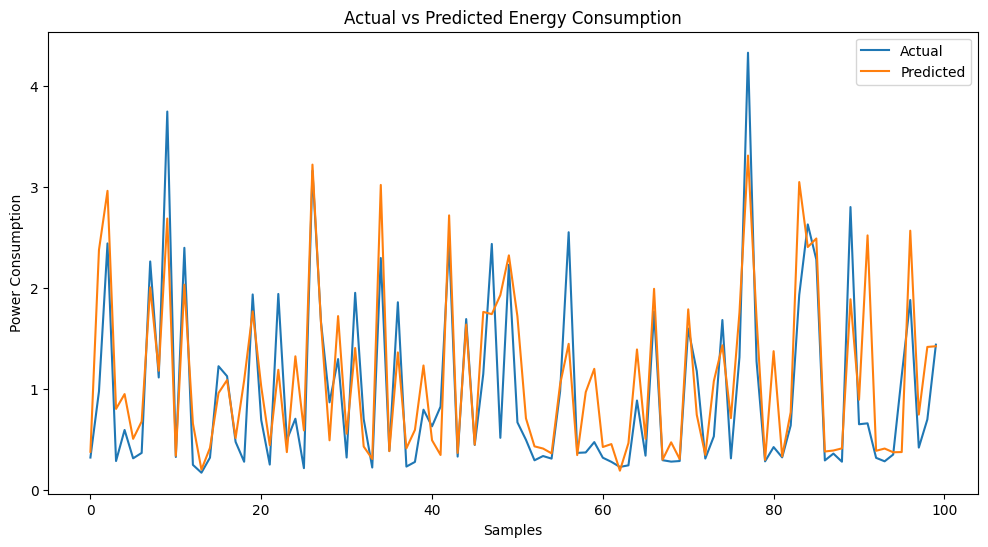

In [26]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values[:100],
    label='Actual'
)

plt.plot(
    predictions[:100],
    label='Predicted'
)

plt.title("Actual vs Predicted Energy Consumption")
plt.xlabel("Samples")
plt.ylabel("Power Consumption")

plt.legend()

plt.show()